In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
#Step 1 - load the data
DATA = Path("../results/cox")

emt_scores = pd.read_csv(DATA/"cox_input_emt_only.tsv", sep="\t", index_col=0)
cox_output = pd.read_csv(DATA/"cox_emt_summary.tsv", sep="\t", index_col=0)

print("EMT scores:", emt_scores.shape)
print("Cox proportional hazards model output:", cox_output)

EMT scores: (291, 3)
Cox proportional hazards model output:                coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
EMT        0.620662    1.86016  0.254776        0.121311        1.120014   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
EMT                   1.128976             3.064897     0.0  2.436112   

                  p  -log2(p)  
covariate                      
EMT        0.014846  6.073775  


In [3]:
emt_scores.head()

,time_days,event,EMT
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a,1263.0,0,0.443655
d9096909-1439-462d-b69c-cad1bf4f420c,940.0,0,-0.077657
29c17355-d646-48da-9e54-7b6dd85dd610,954.0,0,0.766772
29bcba51-2580-473d-9cf7-bedbd0dbad1b,442.0,1,0.234863
ad97b334-e034-4d33-a4d5-48c32d5d521c,2859.0,1,0.193496


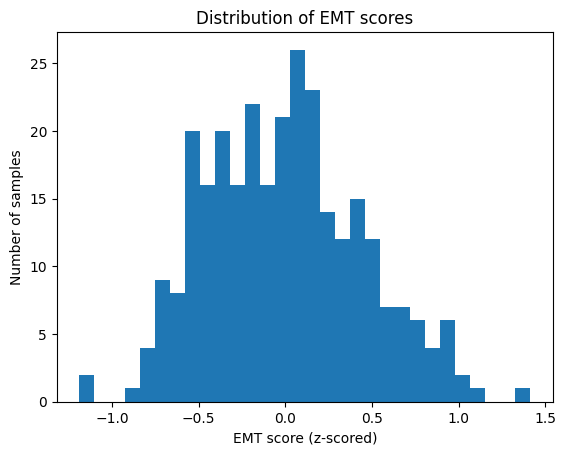

In [4]:
#Step 1 - EMT score distribution
plt.hist(emt_scores["EMT"], bins=30)
plt.xlabel("EMT score (z-scored)")
plt.ylabel("Number of samples")
plt.title("Distribution of EMT scores")
plt.show()

/tmp/ipykernel_52187/1037899172.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


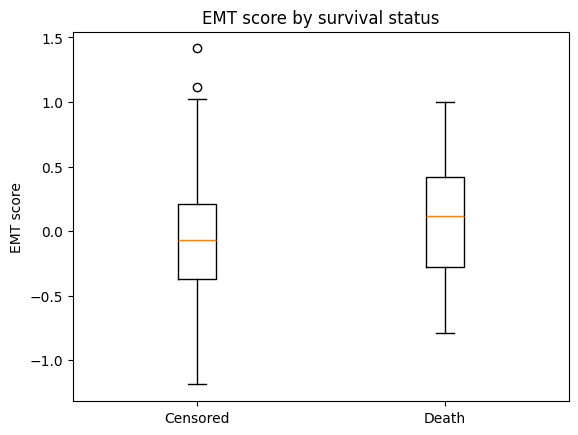

In [5]:
#Step 2 - EMT vs event status
plt.boxplot(
    [emt_scores.loc[emt_scores["event"] == 0, "EMT"],
     emt_scores.loc[emt_scores["event"] == 1, "EMT"]],
    labels=["Censored", "Death"]
)
plt.ylabel("EMT score")
plt.title("EMT score by survival status")
plt.show()


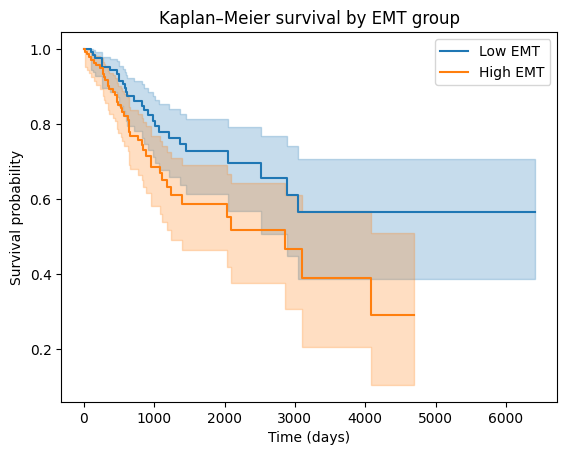

In [6]:
#Step 3 - Kaplan-Meier survival curves
from lifelines import KaplanMeierFitter

emt_scores["EMT_group"] = emt_scores["EMT"] > emt_scores["EMT"].median()

kmf = KaplanMeierFitter()

plt.figure()
for label, g in emt_scores.groupby("EMT_group"):
  kmf.fit(g["time_days"], g["event"],
          label="High EMT" if label else "Low EMT")
  kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier survival by EMT group")
plt.show()

In [7]:
#Step 4 - Log-rank test
from lifelines.statistics import logrank_test

high = emt_scores[emt_scores["EMT_group"]]
low = emt_scores[~emt_scores["EMT_group"]]

lr = logrank_test(
  high["time_days"], low["time_days"],
  event_observed_A=high["event"],
  event_observed_B=low["event"]
)

lr.p_value

np.float64(0.015550345040449129)